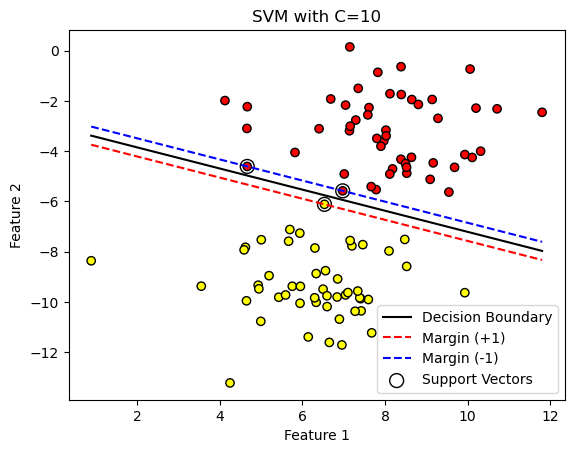

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.svm import SVC

# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=1.5)

# Create SVM model with C control
# Experiment with different values of C to observe the effect
C_value = 10  # Adjust this to higher or lower values
model = SVC(kernel='linear', C=C_value)
model.fit(X, y)

# Get the coefficients of the decision boundary
w = model.coef_[0]
b = model.intercept_[0]

# Plot the data points and the decision boundary
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='autumn', edgecolors='k')

# Decision boundary: w0*x + w1*y + b = 0
x_values = np.linspace(min(X[:, 0]), max(X[:, 0]), 100)
y_values = -(w[0] / w[1]) * x_values - b / w[1]
plt.plot(x_values, y_values, 'k', label='Decision Boundary')

# Plot margins: w0*x + w1*y + b = ±1
margin1 = y_values + 1 / w[1]
margin2 = y_values - 1 / w[1]
plt.plot(x_values, margin1, 'r--', label='Margin (+1)')
plt.plot(x_values, margin2, 'b--', label='Margin (-1)')

# Highlight support vectors
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
            s=100, facecolors='none', edgecolors='k', label='Support Vectors')

plt.title(f"SVM with C={C_value}")
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


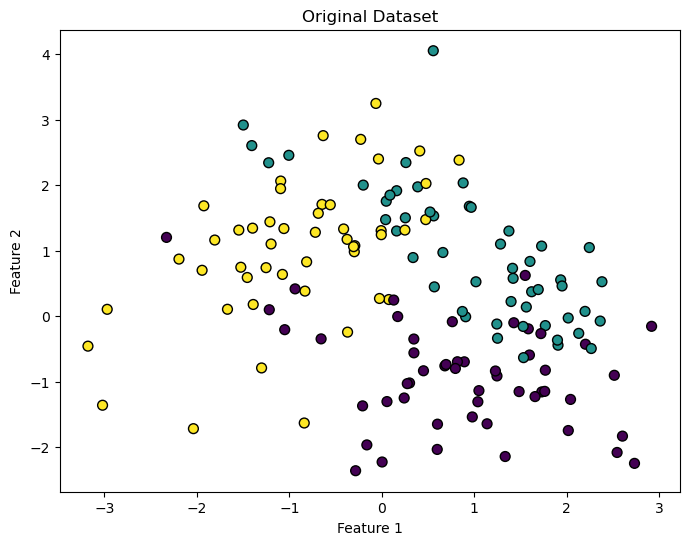

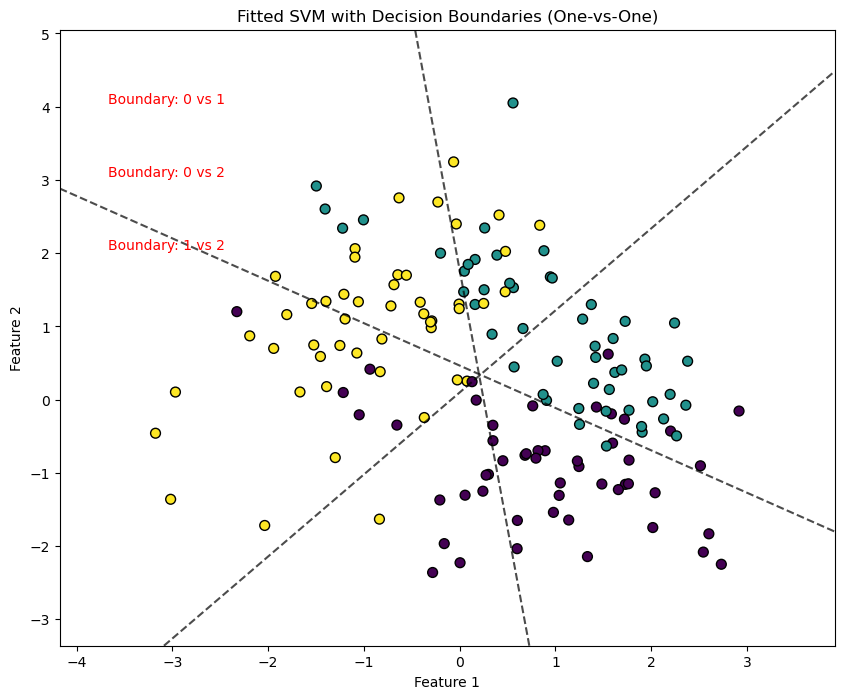

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from itertools import combinations

# Generate a synthetic dataset with 3 classes
np.random.seed(0)
X, y = datasets.make_classification(
    n_classes=3, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, n_samples=150
)

# Plot the original dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=50)
plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Train one-vs-one classifiers
pairs = list(combinations(np.unique(y), 2))  # Pairwise combinations of classes
models = []

for (class_1, class_2) in pairs:
    # Select data belonging to the current pair of classes
    indices = np.where((y == class_1) | (y == class_2))
    X_pair, y_pair = X[indices], y[indices]
    y_pair = np.where(y_pair == class_1, 0, 1)  # Relabel classes as 0 and 1

    # Train SVM classifier
    clf = SVC(kernel="linear")
    clf.fit(X_pair, y_pair)
    models.append((clf, class_1, class_2))

# Plot decision boundaries along with the fitted data points
plt.figure(figsize=(10, 8))

# Plot the dataset points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k", s=50)

# Define the plot space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

for model, class_1, class_2 in models:
    # Get the decision boundary
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    # Plot decision boundary
    plt.contour(xx, yy, Z, levels=[0], linestyles=["--"], colors="k", alpha=0.7)
    
    # Mark the boundary for identification
    plt.text(
        x_min + 0.5,
        y_max - (class_1 + class_2),
        f"Boundary: {class_1} vs {class_2}",
        fontsize=10,
        color="red",
    )

plt.title("Fitted SVM with Decision Boundaries (One-vs-One)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


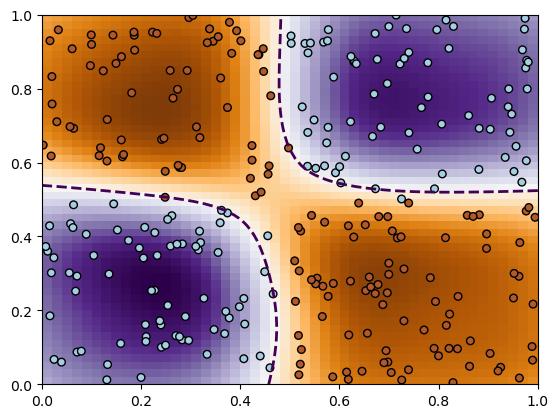

In [5]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import svm
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.random.rand(300, 2)
Y = np.logical_xor(X[:, 0] > 0.5, X[:, 1] > 0.5)

# Fit the model with RBF kernel and specify gamma
clf = svm.NuSVC(gamma=20)
clf.fit(X, Y)

# Plot the decision function for each datapoint on the grid
xx, yy = np.meshgrid(np.linspace(0, 1, 50), np.linspace(0, 1, 50))
Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the decision boundary and scatter points
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    aspect="auto",
    origin="lower",
    cmap=plt.cm.PuOr_r,
)
contours = plt.contour(xx, yy, Z, levels=[0], linewidths=2, linestyles="dashed")
plt.scatter(X[:, 0], X[:, 1], c=Y, s=30, cmap=plt.cm.Paired, edgecolors="k")
plt.show()
